# LQ Benchmark

This notebook is the clean LQ validation page. It starts with the main figures one would expect for the benchmark, then moves the estimator diagnostics and audit tables into a separate appendix.

## Environment Basics

- State space: $\mathcal X=\mathbb R$, with scalar state $X_t$.
- Action space: $\mathcal A=\mathbb R$, with scalar control $u_t$.
- Population signal: the mean $m_t=\mathbb E[X_t]$; the variance $v_t=\operatorname{Var}(X_t)$ is tracked because the LQ oracle is closed form.
- Objective: minimize the finite-horizon cost $J(\theta)$.

The dynamics and policy are

$$
X_{t+1}=aX_t+b u_t+c m_t+\sigma\xi_{t+1},
\qquad
u_t^\theta(du\mid x,m)=\mathcal N(\theta_{t,0}x+\theta_{t,1}m,\sigma_\pi^2)(du).
$$

The unperturbed cost is

$$
J(\theta)=\sum_{t=0}^{T-1}\left(q\,\mathbb E[X_t^2]+r\,\mathbb E[u_t^2]+\gamma m_t^2\right)
+q_T\mathbb E[X_T^2]+\gamma_Tm_T^2.
$$

The continuous MF-REINFORCE perturbation used for this benchmark is the affine mean-law perturbation from the reference notes,

$$
\widehat m_t^{\lambda}=(1+\lambda\zeta_t)m_t+\lambda\beta_t,
\qquad
\zeta_t,\beta_t\sim\mathcal N(0,\rho^2),
$$

which induces the perturbed objective $J^\lambda(\theta)$. The Riccati solution gives the exact unperturbed optimizer $\theta^\star$ and serves as the reference solution.


In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

from mfc.experiments import notebook_helpers as nh

ENV_NAME = "lq"
BASE_DIR = ROOT / "runs" / "extended_benchmark_bundles" / ENV_NAME
PRESET = "mid"
QUICK = PRESET == "smoke"
RUN_MISSING = False
FORCE_REBUILD = False
EXTENDED = True


In [2]:
bundle = (
    nh.ensure_continuous_benchmark_bundle(
        ENV_NAME,
        BASE_DIR,
        quick=QUICK,
        force=FORCE_REBUILD,
        extended=EXTENDED,
        preset=PRESET,
    )
    if RUN_MISSING
    else nh.continuous_bundle_paths(ENV_NAME, BASE_DIR)
)

histories = nh.load_training_histories(bundle)
application = nh.load_application_data(bundle)
studies = nh.load_study_data(bundle)
grid_metrics = nh.load_study_grid_metrics(bundle)
diagnostics = nh.load_diagnostic_data(bundle)
optimization_history = nh.load_optimization_history(bundle)

bundle


{'env': 'lq',
 'base_dir': PosixPath('/home/adonis/Internship/MFC_RL/runs/extended_benchmark_bundles/lq'),
 'train': {'continuous-mfreinforce': PosixPath('/home/adonis/Internship/MFC_RL/runs/extended_benchmark_bundles/lq/train/lq_continuous-mfreinforce'),
  'continuous-oracle-sensitivity': PosixPath('/home/adonis/Internship/MFC_RL/runs/extended_benchmark_bundles/lq/train/lq_continuous-oracle-sensitivity'),
  'reinforce': PosixPath('/home/adonis/Internship/MFC_RL/runs/extended_benchmark_bundles/lq/train/lq_reinforce'),
  'exact-gradient': PosixPath('/home/adonis/Internship/MFC_RL/runs/extended_benchmark_bundles/lq/train/lq_exact-gradient')},
 'application': {'continuous-mfreinforce': PosixPath('/home/adonis/Internship/MFC_RL/runs/extended_benchmark_bundles/lq/application/lq_continuous-mfreinforce'),
  'continuous-oracle-sensitivity': PosixPath('/home/adonis/Internship/MFC_RL/runs/extended_benchmark_bundles/lq/application/lq_continuous-oracle-sensitivity'),
  'reinforce': PosixPath('/hom

## Main Results

These are the core LQ figures.

1. **Validation reward over training**: plots $-J(\theta_k)$, so higher is better. The dashed line is the exact Riccati optimum $-J(\theta^\star)$.
2. **Perturbed objective comparison**: plots $J^\lambda(\hat\theta)$ for saved learned policies, so lower is better. This checks how policies behave under the same affine law perturbation used by continuous MF-REINFORCE.
3. **Theta comparison**: compares learned gains $\theta_{t,0}$ and $\theta_{t,1}$ with the Riccati gains.
4. **Learned policy behavior**: compares the induced mean and variance trajectories with the Riccati trajectory.

The summary table reports the exact final cost gap against the Riccati controller.


,algorithm,learned_cost_J,riccati_cost_J_star,cost_gap
0,continuous MF-REINFORCE,73.190331,4.895598,68.294732
1,"MF-REINFORCE, oracle $D_t$",60.395048,4.895598,55.499449
2,classical REINFORCE,46.974716,4.895598,42.079118
3,exact gradient,52.470186,4.895598,47.574588


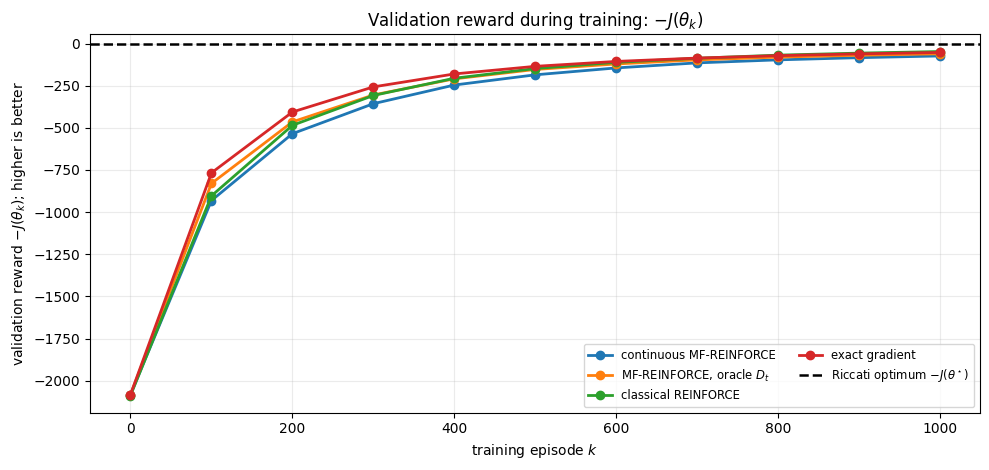

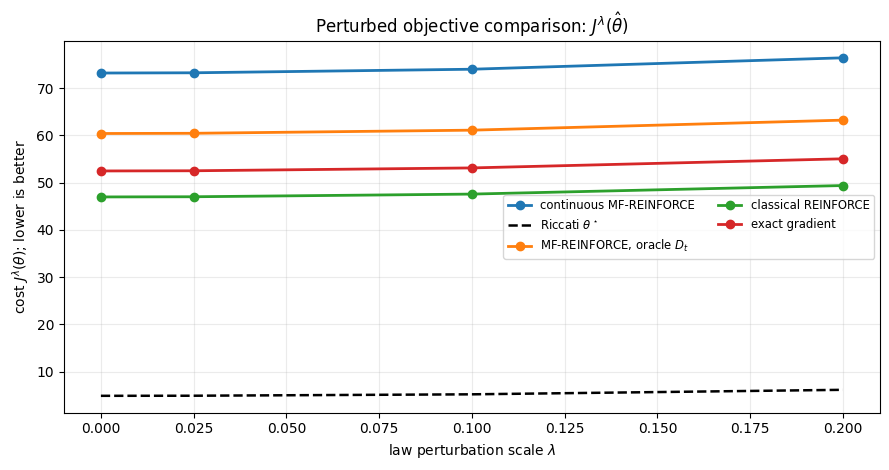

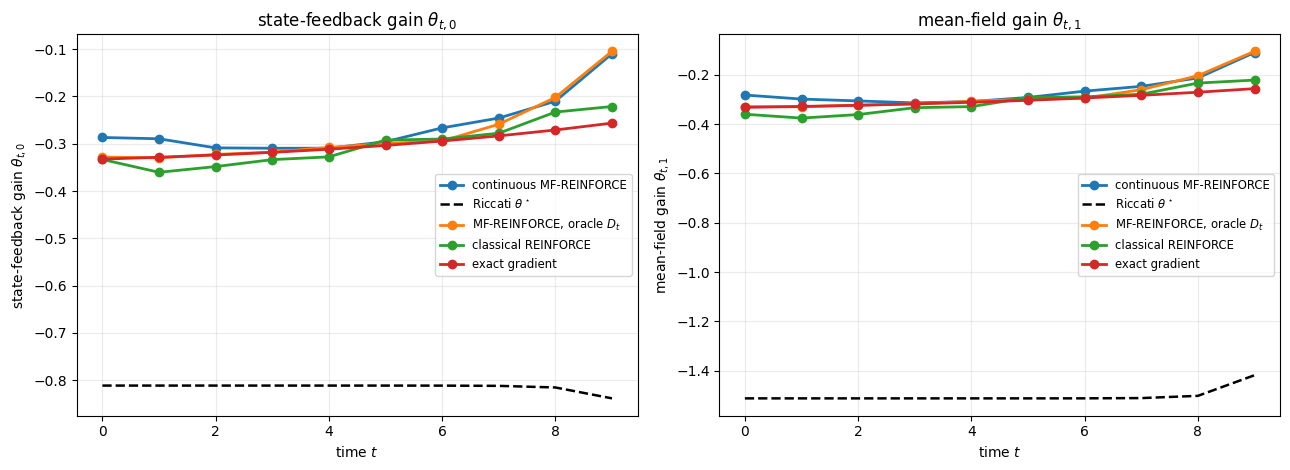

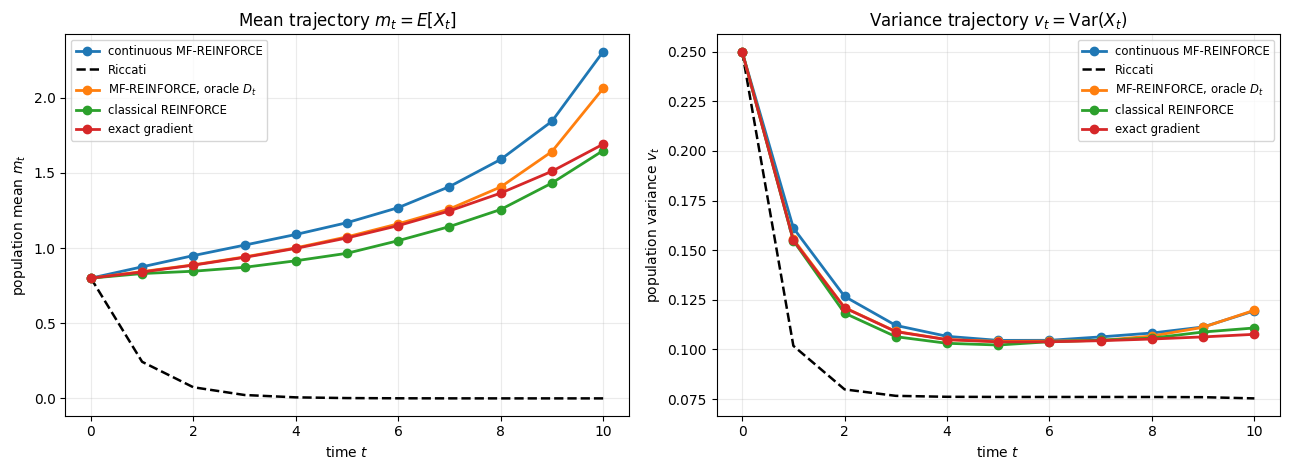

In [3]:
display(nh.lq_main_summary_table(application))
nh.plot_lq_main_results(bundle, histories, application, studies)


## Estimator Diagnostic Appendix

These plots are not the headline result; they explain whether the estimator chain is behaving sensibly.

The panels summarize:

$$
E[d(M^\lambda,\mu)],
\qquad
\frac{\|E[\widehat g]-g\|}{\|g\|},
\qquad
\operatorname{tr}\operatorname{Cov}(S_\lambda),
\qquad
E\|\widehat D_t-D_t\|^2.
$$

This is the compact replacement for the older long block of perturbation, functional-law, score, gradient, and sensitivity figures.


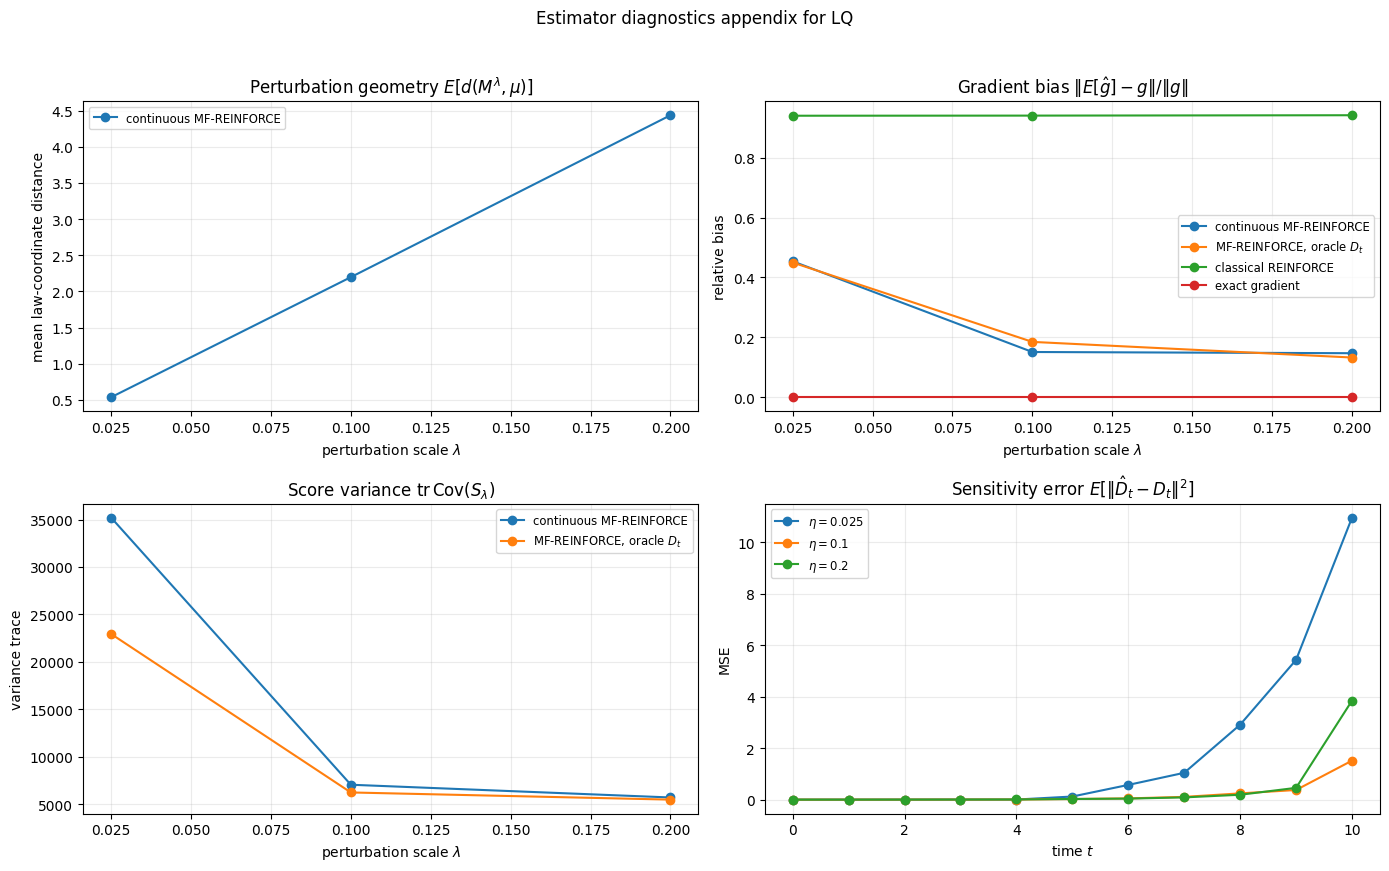

In [4]:
nh.plot_lq_diagnostic_appendix(diagnostics, studies, grid_metrics)


## Optional Optimization And Budget Tables

Use this section when checking runtime, budget allocation, or extended-study outputs. It is intentionally separate from the main benchmark story.


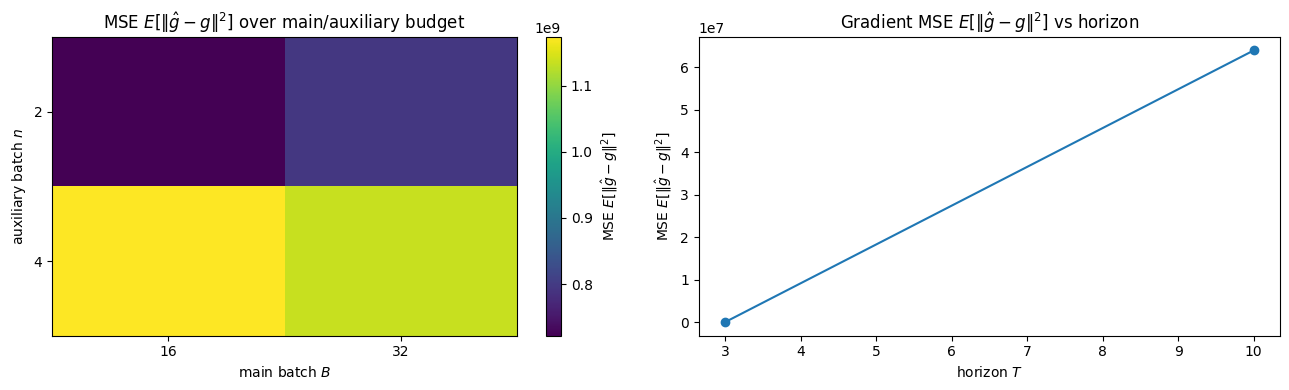

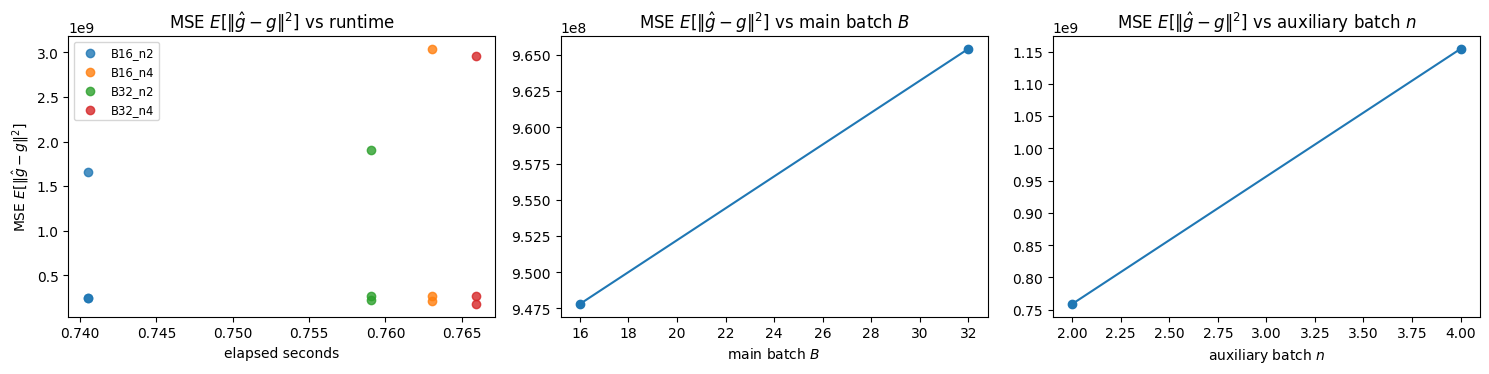

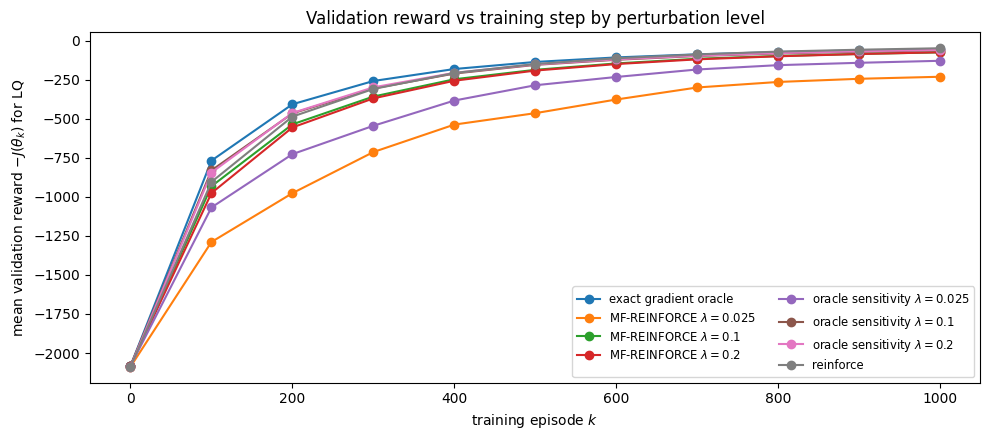

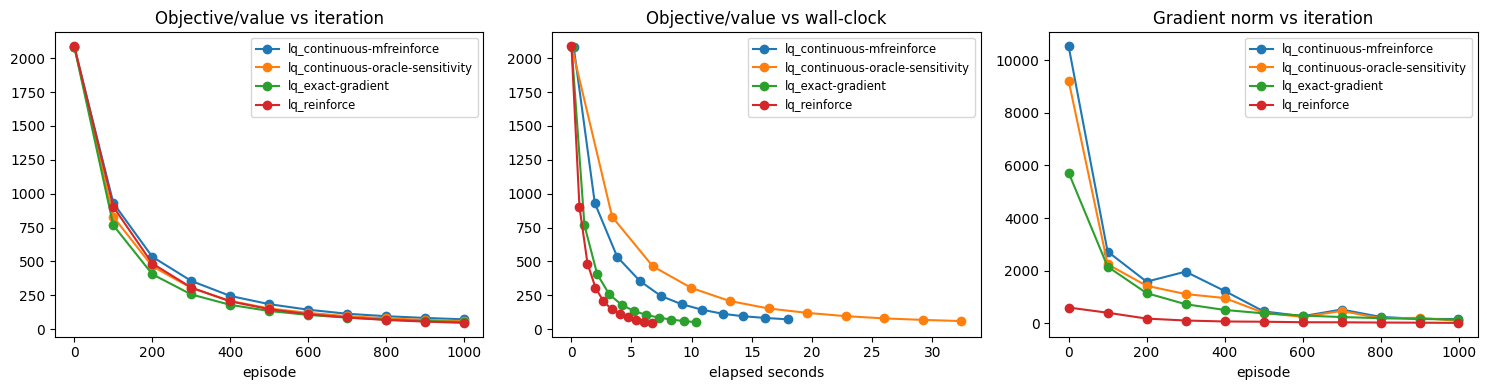

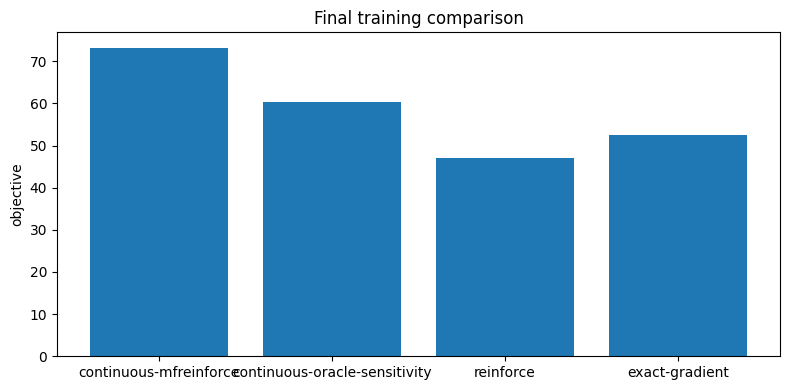

In [5]:
nh.plot_budget_and_horizon(studies)
nh.plot_budget_pareto(studies, grid_metrics)
nh.plot_lambda_training_comparison(studies)
nh.plot_optimization_history(optimization_history)
nh.plot_optimization_summary(studies)


## Figure Coverage Audit

These tables map the broader requested figure list to saved artifacts. They are useful for project management, not for reading the LQ result.


In [6]:
nh.figure_checklist(ENV_NAME)


,figure_family,command_or_study,files,notebook_section
0,perturbation_geometry,diagnose-perturbation,"diagnostics.csv, perturbation_samples.csv",universal diagnostics
1,functional_law,diagnose-functional-law,"diagnostics.csv, signature_samples.csv, functi...",universal diagnostics
2,score_validation,score-validation,"diagnostics.csv, score_coordinates.csv, score_...",universal diagnostics
3,gradient_validation,diagnose-gradient,"diagnostics.csv, gradient_samples.csv, gradien...",universal diagnostics
4,sensitivity_validation,diagnose-sensitivity,"diagnostics.csv, sensitivity_samples.csv",universal diagnostics
5,horizon_scaling,horizon-scaling,"grid_metrics.csv, diagnostics.csv",study sweeps
6,budget_allocation,budget-allocation,"grid_metrics.csv, diagnostics.csv",study sweeps
7,particle_approximation,particle-approximation,"grid_metrics.csv, diagnostics.csv",study sweeps
8,particle_transfer,particle-transfer,"diagnostics.csv, optimization_history.csv",study sweeps
9,ablation,ablation,"grid_metrics.csv, diagnostics.csv",study sweeps


In [7]:
nh.figure_coverage_matrix(ENV_NAME)


,figure_or_result,status,notebook_helper,artifact
0,"perturbation mean, bands, and empirical slopes",ready,"plot_perturbation_geometry, plot_perturbation_...",diagnostics/*_perturbation/diagnostics.csv
1,finite-state d_TV perturbation calibration and...,ready,"perturbation_tv_comparison_table, plot_perturb...","diagnostics/*_perturbation/diagnostics.csv, di..."
2,functional-law signature summaries,ready,"plot_functional_law, plot_functional_signature...",diagnostics/*_functional_law/diagnostics.csv
3,"functional-law histograms, pair plots, Q-Q plots",ready,plot_functional_sample_diagnostics,diagnostics/*_functional_law/signature_samples...
4,"score mean, variance, lambda^2 variance, coord...",ready,"plot_score_validation, plot_score_coordinate_d...",diagnostics/*_score/*.csv
5,"gradient bias, variance, MSE, cosine, norm, de...",ready,"plot_gradient_validation, plot_gradient_error_...",diagnostics/*_gradient/diagnostics.csv
6,coordinatewise gradient scatter and CI coverage,ready,plot_gradient_coordinate_diagnostics,diagnostics/*_gradient/gradient_coordinates.cs...
7,sensitivity error vs time/eta and heatmap,ready,"plot_sensitivity_validation, plot_sensitivity_...",diagnostics/*_sensitivity/diagnostics.csv
8,budget allocation heatmap and runtime Pareto,ready,"plot_budget_and_horizon, plot_budget_pareto",studies/budget_allocation/*.csv
9,horizon scaling,ready,plot_budget_and_horizon,studies/horizon_scaling/*.csv


## Raw Tables For Custom Figures

The first few rows below are the main saved tables used by the plots above.


In [8]:
application[nh.CONTINUOUS_ALGORITHM]["time_metrics"].head(), diagnostics[nh.CONTINUOUS_ALGORITHM]["gradient"].head(), studies["budget"].head()


(  env  time      mean  variance  optimal_mean  optimal_variance  mean_error  \
 0  lq     0  0.800000  0.250000      0.800000          0.250000    0.000000   
 1  lq     1  0.875214  0.161199      0.243423          0.101831    0.631792   
 2  lq     2  0.949968  0.126711      0.074068          0.079888    0.875900   
 3  lq     3  1.019676  0.112118      0.022537          0.076638    0.997139   
 4  lq     4  1.090435  0.106619      0.006858          0.076156    1.083578   
 
    variance_error  
 0        0.000000  
 1        0.059368  
 2        0.046824  
 3        0.035480  
 4        0.030463  ,
    lambda  replications  estimate_norm  variance_trace  \
 0   0.025             8    3789.150203    1.372922e+08   
 1   0.100             8    5166.948310    3.221227e+07   
 2   0.200             8    5795.820814    4.033776e+07   
 
    covariance_largest_eigenvalue  oracle_norm    bias_norm  relative_bias  \
 0                   1.099533e+08  5731.779086  2601.847435       0.453934 